In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv("blinkit_data.csv")
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0


In [14]:
df.shape

(8523, 12)

In [15]:
df.isnull().sum()

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Sales                           0
Rating                          0
dtype: int64

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item Fat Content           8523 non-null   object 
 1   Item Identifier            8523 non-null   object 
 2   Item Type                  8523 non-null   object 
 3   Outlet Establishment Year  8523 non-null   int64  
 4   Outlet Identifier          8523 non-null   object 
 5   Outlet Location Type       8523 non-null   object 
 6   Outlet Size                8523 non-null   object 
 7   Outlet Type                8523 non-null   object 
 8   Item Visibility            8523 non-null   float64
 9   Item Weight                7060 non-null   float64
 10  Sales                      8523 non-null   float64
 11  Rating                     8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [17]:
for col in df.select_dtypes(include="object").columns:
    print(f"{col}\n")
    print(f"{df[col].value_counts().reset_index()}\n")

Item Fat Content

  Item Fat Content  count
0          Low Fat   5089
1          Regular   2889
2               LF    316
3              reg    117
4          low fat    112

Item Identifier

     Item Identifier  count
0              FDW13     10
1              FDG33     10
2              FDX20      9
3              NCL31      9
4              FDQ40      9
...              ...    ...
1554           FDN52      1
1555           FDQ60      1
1556           FDT35      1
1557           FDK57      1
1558           FDE52      1

[1559 rows x 2 columns]

Item Type

                Item Type  count
0   Fruits and Vegetables   1232
1             Snack Foods   1200
2               Household    910
3            Frozen Foods    856
4                   Dairy    682
5                  Canned    649
6            Baking Goods    648
7      Health and Hygiene    520
8             Soft Drinks    445
9                    Meat    425
10                 Breads    251
11            Hard Drinks    214
12    

**Data Cleaning**

In [18]:
df["Item Fat Content"]=df["Item Fat Content"].replace({"reg":"Regular","LF":"Low Fat","low fat":"Low Fat"})

In [19]:
df["Item Fat Content"].value_counts()

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

### Business Requirements

**KPI's Requirements**

In [20]:
total_sales=df["Sales"].sum()
average_sales=df["Sales"].mean()
num_of_items_sold=df["Sales"].count()
avg_ratings=df["Rating"].mean()

print("Total Sales: $",round(total_sales,2))
print("Average Sales: $",round(average_sales,2))
print("Num of Items: ",round(num_of_items_sold,2))
print("Average Ratings: ",round(avg_ratings,2))

Total Sales: $ 1201681.48
Average Sales: $ 140.99
Num of Items:  8523
Average Ratings:  3.97


**Chart's Requirements**

- Total Sales By Fat Content

In [21]:
sales_by_fat=df.groupby("Item Fat Content")["Sales"].sum()

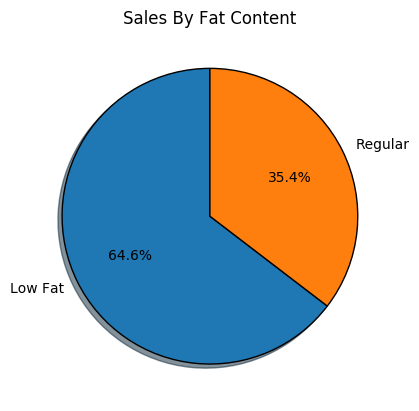

In [22]:
plt.pie(x=sales_by_fat,labels=sales_by_fat.index,autopct="%0.1f%%",startangle=90,wedgeprops={"edgecolor":"black"},shadow=True)
plt.title("Sales By Fat Content")
plt.show()

- Total Sales By Item Type

In [25]:
sales_by_item_type=df.groupby("Item Type")["Sales"].sum().sort_values(ascending=False)

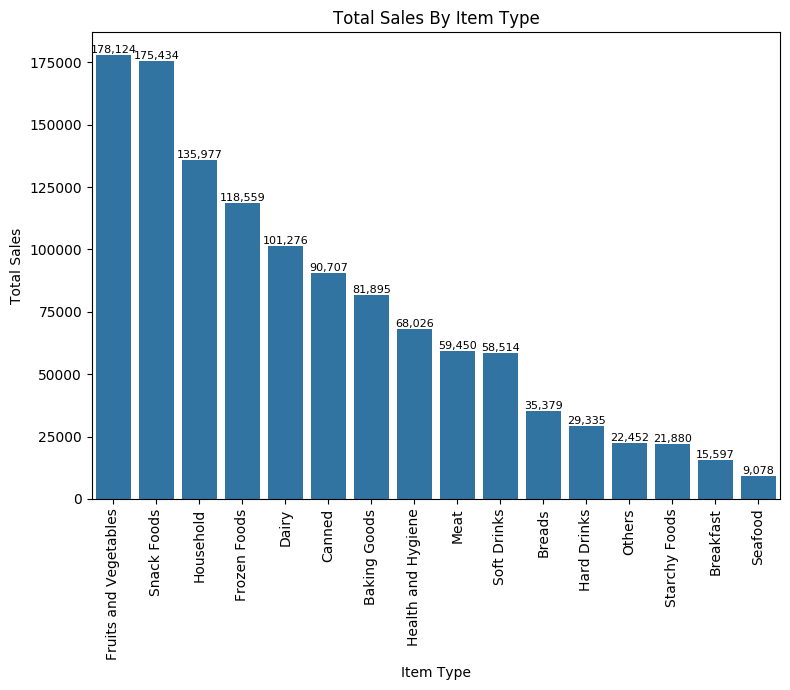

In [29]:
plt.figure(figsize=(8,7))
ax=sns.barplot(x=sales_by_item_type.index,y=sales_by_item_type.values)
plt.xticks(rotation=90)
plt.xlabel("Item Type")
plt.ylabel("Total Sales")
plt.title("Total Sales By Item Type")

for bar in ax.patches:
    plt.text(bar.get_x()+bar.get_width()/2,bar.get_height(),f'{bar.get_height():,.0f}', ha='center',va='bottom',fontsize=8)
plt.tight_layout()
plt.show()

- Fat Content by Outlet for Total Sales

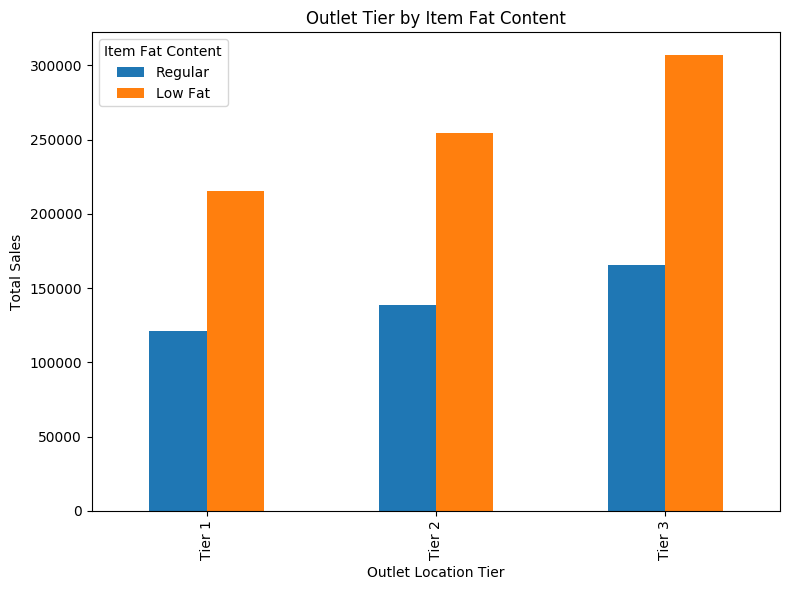

In [32]:
grouped=df.groupby(["Outlet Location Type","Item Fat Content"])["Sales"].sum().unstack()
grouped=grouped[["Regular","Low Fat"]]

ax=grouped.plot(kind="bar",figsize=(8,6),title="Outlet Tier by Item Fat Content")
plt.xlabel("Outlet Location Tier")
plt.ylabel("Total Sales")
plt.legend(title="Item Fat Content")
plt.tight_layout()
plt.show()

- Total Sales by Outlet Establishment

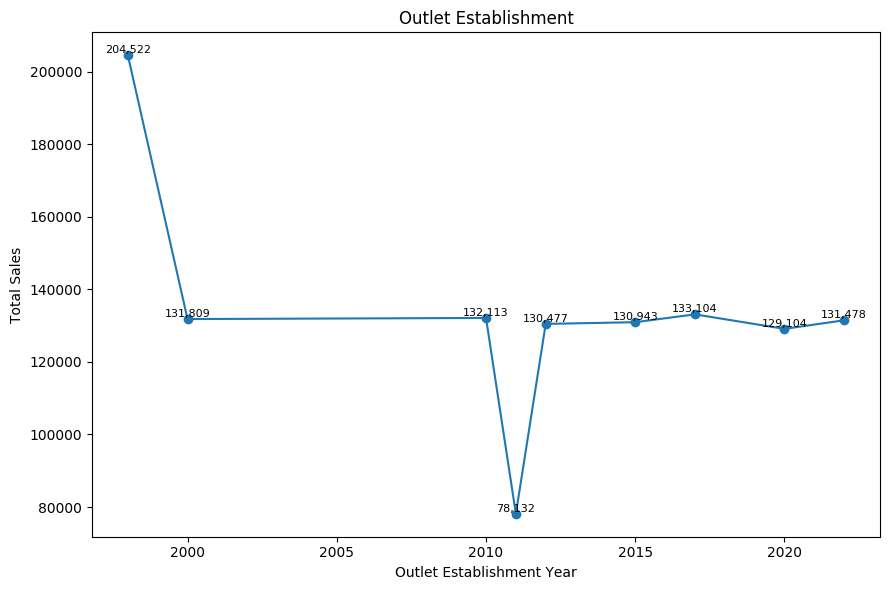

In [34]:
sales_by_year=df.groupby("Outlet Establishment Year")["Sales"].sum().sort_index()

plt.figure(figsize=(9,6))
plt.plot(sales_by_year.index,sales_by_year.values,marker="o",linestyle="-")
plt.xlabel("Outlet Establishment Year")
plt.ylabel("Total Sales")
plt.title("Outlet Establishment")

for x,y in zip(sales_by_year.index,sales_by_year.values):
    plt.text(x,y,f'{y:,.0f}',ha="center",va="bottom",fontsize=8)
plt.tight_layout()
plt.show()

- Sales by Outlet Size

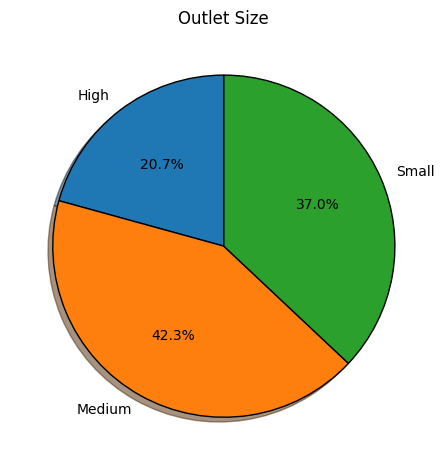

In [36]:
sales_by_size=df.groupby("Outlet Size")["Sales"].sum()
plt.pie(x=sales_by_size,labels=sales_by_size.index,autopct="%0.1f%%",startangle=90,shadow=True,wedgeprops={"edgecolor":"black"})
plt.title("Outlet Size")
plt.tight_layout()
plt.show()

- Sales by Outlet Location

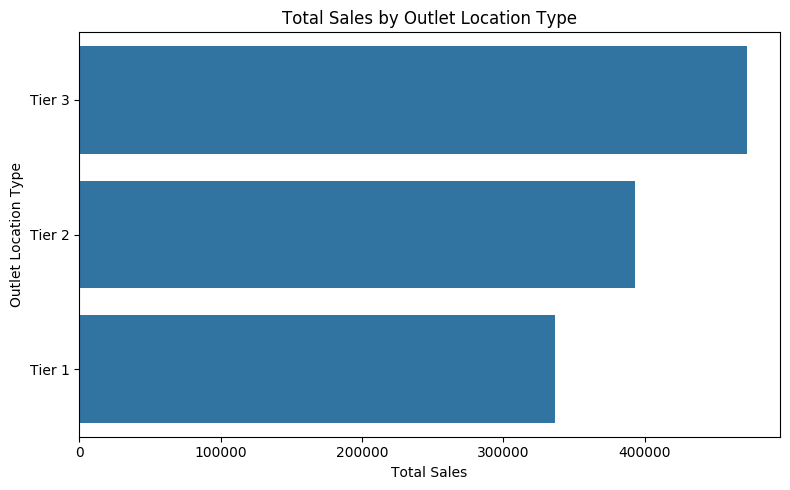

In [38]:
sales_by_location=df.groupby("Outlet Location Type")["Sales"].sum().reset_index().sort_values("Sales",ascending=False)
plt.figure(figsize=(8,5))
ax=sns.barplot(x="Sales",y="Outlet Location Type",data=sales_by_location)
plt.title("Total Sales by Outlet Location Type")
plt.xlabel("Total Sales")
plt.ylabel("Outlet Location Type")
plt.tight_layout()
plt.show()